## Imports

In [45]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split

## Data Importing

In [6]:
train = pd.read_csv('../../data/tweet_sentiment_data.csv')
train.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


## Data Exploration

In [7]:
len(train)

27481

In [8]:
train['sentiment'].unique()

<ArrowStringArray>
['neutral', 'negative', 'positive']
Length: 3, dtype: str

In [9]:
train.groupby('sentiment').nunique()

,textID,text,selected_text
sentiment,,,
negative,7781,7781,5861
neutral,11118,11117,11111
positive,8582,8582,5537


## Data Cleaning

In [28]:
import re
import gensim
from nltk.tokenize.treebank import TreebankWordDetokenizer

In [10]:
train = train[['selected_text', 'sentiment']]
train.head()

,selected_text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD,negative
2,bullying me,negative
3,leave me alone,negative
4,"Sons of ****,",negative


In [11]:
train['selected_text'].isnull().sum()

np.int64(1)

In [15]:
train['selected_text'] = train['selected_text'].fillna("No content")

##### For further cleaning:
- Remove urls from tweets
- tokenize text
- remove emails
- remove new line characters
- remove distracting single quotes
- lowercase all text
- detokenize text
- convert list of text to numpy array

In [ ]:
def depure_data(data):
    
    # Removing URLs
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    data = url_pattern.sub('', data)

    # Remove Emails
    data = re.sub(r'\s*@\s*\s?', '', data)

    # Remove new line characters
    data = re.sub(r'\s+', ' ', data)

    # Remove distracting single quotes
    data = re.sub(r"'", "", data)
        
    return data

In [22]:
temp = []
#splitting pd.series to list
data_to_list = train['selected_text'].values.tolist()
for i in range(len(data_to_list)):
    temp.append(depure_data(data_to_list[i]))
list(temp[:5])

['I`d have responded, if I were going',
 'Sooo SAD',
 'bullying me',
 'leave me alone',
 'Sons of ****,']

In [ ]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

data_words = list(sent_to_words(temp))
print(data_words[:10])

[['have', 'responded', 'if', 'were', 'going'], ['sooo', 'sad'], ['bullying', 'me'], ['leave', 'me', 'alone'], ['sons', 'of'], ['some', 'shameless', 'plugging', 'for', 'the', 'best', 'rangers', 'forum', 'on', 'earth'], ['fun'], ['soooo', 'high'], ['both', 'of', 'you'], ['wow', 'just', 'became', 'cooler']]


In [25]:
len(data_words)

27481

In [26]:
def detokenize(text):
    return TreebankWordDetokenizer().detokenize(text)

In [29]:
data = []
for i in range(len(data_words)):
    data.append(detokenize(data_words[i]))
print(data[:5])

['have responded if were going', 'sooo sad', 'bullying me', 'leave me alone', 'sons of']


In [30]:
data = np.array(data)

## Label Encoding

In [34]:
import tensorflow as tf

In [36]:
labels = np.array(train['sentiment'])
y = []
for i in range(len(labels)):
    if labels[i] == 'neutral':
        y.append(0)
    if labels[i] == 'negative':
        y.append(1)
    if labels[i] == 'positive':
        y.append(2)
y = np.array(y)
labels = tf.keras.utils.to_categorical(y, 3)
del y

In [37]:
len(labels)

27481

## Data sequencing and splitting

In [ ]:
from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop,Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras import regularizers
from keras import backend as K
from keras.callbacks import ModelCheckpoint

In [43]:
max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(data)
sequences = tokenizer.texts_to_sequences(data)
tweets = pad_sequences(sequences, maxlen=max_len)
print(tweets)
print(labels)

[[   0    0    0 ...   68  146   41]
 [   0    0    0 ...    0  397   65]
 [   0    0    0 ...    0    0   11]
 ...
 [   0    0    0 ...  372   10    3]
 [   0    0    0 ...   24  542    4]
 [   0    0    0 ... 2422  199  656]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [46]:
#splitting the data
X_train, X_test, y_train, y_test = train_test_split(tweets, labels, random_state=0)
print(len(X_train), len(X_test), len(y_train), len(y_test))

20610 6871 20610 6871


## Model Building

In [ ]:
# SimpleRNN Model

model0 = Sequential()
model0.add(layers.Embedding(max_words, 15))
model0.add(layers.SimpleRNN(15))
model0.add(layers.Dense(3, activation='softmax'))

model0.compile(optimizer='rmsprop', 
               loss='categorical_crossentropy', 
               metrics=['accuracy'])

checkpoint0 = ModelCheckpoint("best_model0.hdf5", 
                              monitor='val_accuracy', 
                              verbose=1,
                              save_best_only=True, 
                              mode='auto', 
                              period=1,
                              save_weights_only=False)
history = model0.fit(X_train, y_train, 
                     epochs=5,
                     validation_data=(X_test, y_test),
                     callbacks=[checkpoint0])

In [ ]:
#single LSTM layer model

model1 = Sequential()
model1.add(layers.Embedding(max_words, 20))
model1.add(layers.LSTM(15, dropout=0.5))
model1.add(layers.Dense(3, activation='softmax'))

model1.compile(optimizer='rmsprop',
               loss = 'categorical_crossentropy',
               metrics=['accuracy'])
checkpoint1 = ModelCheckpoint("best_model1.hdf5",
                              monitor='val_accuracy',
                              verbose=1, 
                              save_best_only=True,
                              mode='auto',
                              period=1,
                              save_weights_only=False)
history = model1.fit(X_train, y_train,
                     epochs=70,
                     validation_data=(X_test, y_test),
                     callbacks=[checkpoint1])

In [51]:
# Bidirectional LSTM Model

model2 = Sequential()
model2.add(layers.Embedding(max_words, 40, input_length=max_len))
model2.add(layers.Bidirectional(layers.LSTM(20, dropout=0.6)))
model2.add(layers.Dense(3, activation='softmax'))

model2.compile(optimizer='rmsprop',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
checkpoint2 = ModelCheckpoint("best_model2.keras", 
                              monitor='val_accuracy',
                              verbose=1,
                              save_best_only=True,
                              mode='auto',
                              save_weights_only=False)
history = model2.fit(X_train, y_train,
                     epochs=70,
                     validation_data=(X_test, y_test),
                     callbacks=checkpoint2)

Epoch 1/70


/home/asish-jose/AI-ML/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5707 - loss: 0.8899
Epoch 1: val_accuracy improved from None to 0.73294, saving model to best_model2.keras

Epoch 1: finished saving model to best_model2.keras
645/645 ━━━━━━━━━━━━━━━━━━━━ 52s 76ms/step - accuracy: 0.6298 - loss: 0.8175 - val_accuracy: 0.7329 - val_loss: 0.6907
Epoch 2/70
644/645 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7494 - loss: 0.6331
Epoch 2: val_accuracy improved from 0.73294 to 0.78518, saving model to best_model2.keras

Epoch 2: finished saving model to best_model2.keras
645/645 ━━━━━━━━━━━━━━━━━━━━ 52s 81ms/step - accuracy: 0.7654 - loss: 0.5976 - val_accuracy: 0.7852 - val_loss: 0.5466
Epoch 3/70
645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7961 - loss: 0.5244
Epoch 3: val_accuracy did not improve from 0.78518
645/645 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.7993 - loss: 0.5181 - val_accuracy: 0.7792 - val_loss: 0.5416
Epoch 4/70
645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accu

In [ ]:
# 1D Convolutional model

from keras import regularizers

model3 = Sequential()
model3.add(layers.Embedding(max_words, 40, input_length=max_len))
model3.add(layers.Conv1D(20, 6, activation='relu',kernel_regularizer=regularizers.l1_l2(l1=2e-3, l2=2e-3),bias_regularizer=regularizers.l2(2e-3)))
model3.add(layers.MaxPooling1D(5))
model3.add(layers.Conv1D(20, 6, activation='relu',kernel_regularizer=regularizers.l1_l2(l1=2e-3, l2=2e-3),bias_regularizer=regularizers.l2(2e-3)))
model3.add(layers.GlobalMaxPooling1D())
model3.add(layers.Dense(3,activation='softmax'))
model3.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['acc'])
checkpoint3 = ModelCheckpoint("best_model3.hdf5", monitor='val_accuracy', verbose=1,save_best_only=True, mode='auto', period=1,save_weights_only=False)
history = model3.fit(X_train, y_train, epochs=70,validation_data=(X_test, y_test),callbacks=[checkpoint3])

## Best Model validation

In [54]:
from tensorflow import keras

In [ ]:
best_model = keras.models.load_model("best_model2.keras")



215/215 - 3s - 15ms/step - accuracy: 0.8402 - loss: 0.4440
Model accuracy:  0.8401979207992554


In [57]:
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=2)
print('Model accuracy: ',test_acc)

215/215 - 3s - 14ms/step - accuracy: 0.8402 - loss: 0.4440
Model accuracy:  0.8401979207992554


In [58]:
predictions = best_model.predict(X_test)

215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


## Confusion Matrix

In [59]:
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_test.argmax(axis=1), np.around(predictions, decimals=0).argmax(axis=1))

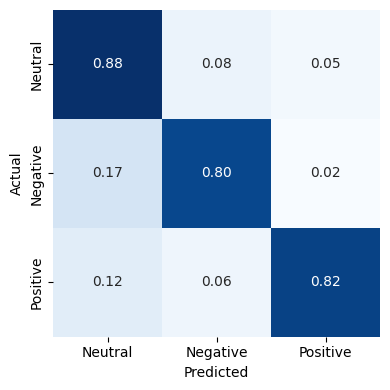

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = pd.DataFrame(
    matrix,
    index=['Neutral','Negative','Positive'],
    columns=['Neutral','Negative','Positive']
)

# Normalize
conf_matrix = conf_matrix.astype(float) / conf_matrix.sum(axis=1).to_numpy()[:, np.newaxis]

plt.figure(figsize=(4,4))  # reduced size
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    annot_kws={"size":10},  # smaller text
    cbar=False
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [66]:
sentiment = ['Neutral','Negative','Positive']

In [67]:
sequence = tokenizer.texts_to_sequences(['this experience has been the worst , want my money back'])
test = pad_sequences(sequence, maxlen=max_len)
sentiment[np.around(best_model.predict(test), decimals=0).argmax(axis=1)[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


'Negative'

In [68]:
sequence = tokenizer.texts_to_sequences(['this data science article is the best ever'])
test = pad_sequences(sequence, maxlen=max_len)
sentiment[np.around(best_model.predict(test), decimals=0).argmax(axis=1)[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


'Positive'

## Preparing model for hosting

In [70]:
#Saving weights and tokenizer so we can reduce training time on SageMaker

# save model architecture
model_json = best_model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

# save weights
best_model.save_weights("model.weights.h5")

print("Model saved")

Model saved


In [71]:
from tensorflow.keras.models import model_from_json

with open("model.json", "r") as json_file:
    model_json = json_file.read()

model = model_from_json(model_json)
model.load_weights("model.weights.h5")